# First Implementation 


There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


In this notebook, the simplest setup is now:

- you directly provide the path to the reference image
- you directly provide the path to the current image

You no longer need to use indices such as `scene_000`, `scene_001`, and so on.


In [1]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import camera
import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Convert to frame, create a list of these frames

In [5]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\output.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel")
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\frames_real")

FPS : 30.0
Nombre total de trames : 101
101 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel
FPS : 30.0
Nombre total de trames : 798
798 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\frames_real


In [6]:
dossier_fake = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\frames")
dossier_real = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel")

In [6]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouvés dans {dossier_fake}")

121 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\frames


In [7]:

real_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_real.rglob("*")
    if f.is_file()
)

print(f"{len(real_frame_paths)} fichiers trouvés dans {dossier_real}")


print()


101 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel



In [8]:

KEYFRAME_PATH = real_frame_paths[0]
TARGET_PATH= real_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00001.png


## 2. Notebook utility functions

Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.


In [9]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


(480, 640)


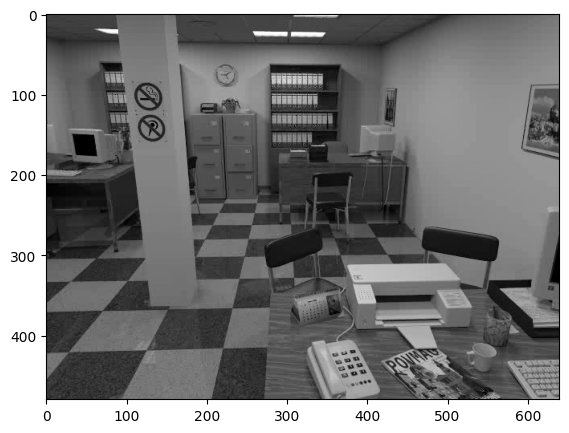

In [10]:
frame_0 = load_gray_image(KEYFRAME_PATH)
print(frame_0.shape)
plt.imshow(frame_0, cmap='gray')

## keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [11]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


xFormers not available
xFormers not available


Depth Anything loaded on cpu (97.47M parameters)


In [12]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00000.png
keyframe_image shape = (480, 640) dtype = uint8
keyframe_depth shape = (480, 640) dtype = float32
depth min/max = 1.8346056938171387 84.0458755493164
valid depth ratio = 1.0


Text(0.5, 1.0, 'Inverse depth')

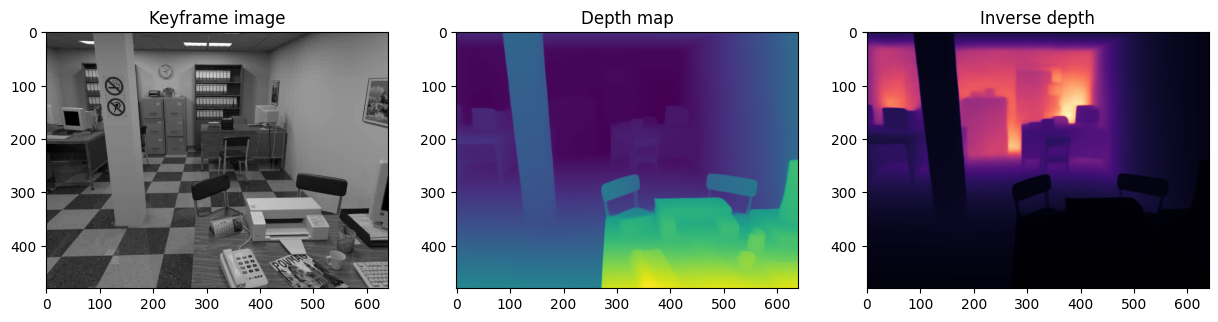

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




## 4. Intrinsics

We add a simple estimate of the intrinsics from the loaded image.

Assumptions:
- `width` and `height` come directly from the image
- `cx` and `cy` are taken at the image center
- `fx` and `fy` are estimated from an assumed horizontal field of view

This is not a true camera calibration, but it is a practical estimate to run the pipeline on new images. If you know the camera better, you can change `DEFAULT_HORIZONTAL_FOV_DEG` or directly replace `fx`, `fy`, `cx`, `cy`.


In [ ]:
# Fixed ground-truth intrinsics used everywhere in this project
height, width = keyframe_image.shape[:2]

#TUM RGB-D dataset intrinsics

#fx = 525.0
#fy = 525.0
#cx = 319.5
#cy = 239.5
#factor = 5000




#Emanuel Dataset intrinsics
width = 640
height = 480
fx = 481.20
fy = 480.0
cx = 319.5
cy = 239.5



intrinsics = {
    "width": width,
    "height": height,
    "fx": fx,
    "fy": fy,
    "cx": cx,
    "cy": cy,
#  "factor": factor,
    "K": np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64),
}





K = intrinsics["K"]
cam = camera.camera(fx, fy, cx, cy, width, height)
K_pipeline_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)







print("Fixed ground-truth intrinsics:")
print("input width =", width)
print("input height =", height)
print("fx =", fx)
print("fy =", fy)
print("cx =", cx)
print("cy =", cy)
#print("factor =", factor)
print()
print("K_input =")
print(K)
print()
print("Pipeline level-0 intrinsics after internal resize:")
print("pipeline width =", cam.width[0])
print("pipeline height =", cam.height[0])
print()
print("K_pipeline_lvl0 =")
print(K_pipeline_lvl0)


Fixed ground-truth intrinsics:
input width = 640
input height = 480
fx = 481.2
fy = 480.0
cx = 319.5
cy = 239.5

K_input =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]

Pipeline level-0 intrinsics after internal resize:
pipeline width = 512
pipeline height = 512

K_pipeline_lvl0 =
[[384.96       0.       255.6     ]
 [  0.       512.       255.466667]
 [  0.         0.         1.      ]]


In [16]:
print(cam.cx[0])
print( cx)

255.60000000000002
319.5


In [17]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(512, 512), invDepth=(512, 512), grad=(512, 512, 2)
level 1: image=(256, 256), invDepth=(256, 256), grad=(256, 256, 2)
level 2: image=(128, 128), invDepth=(128, 128), grad=(128, 128, 2)
level 3: image=(64, 64), invDepth=(64, 64), grad=(64, 64, 2)
level 4: image=(32, 32), invDepth=(32, 32), grad=(32, 32, 2)


## 5. Loading the current image

Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.


In [18]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

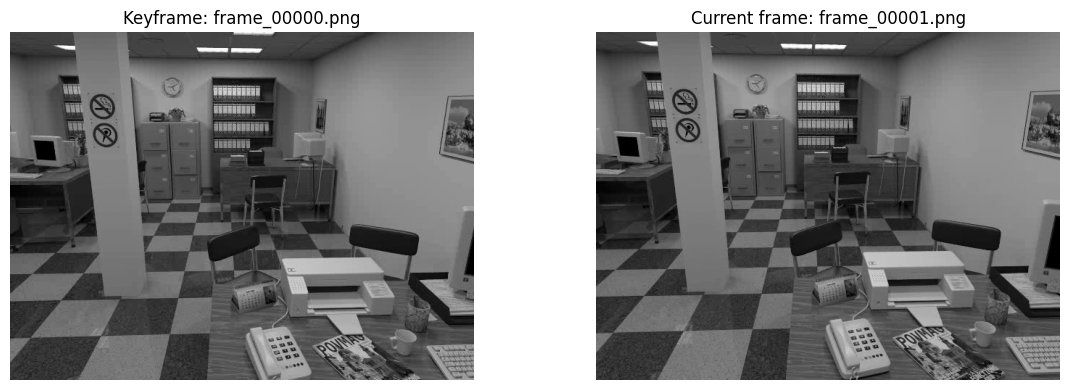

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Initial pose and optimization updates


In [19]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)




print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Initial photometric errors before optimization:
  level 4 = 2004.3798627002259
  level 3 = 1857.0992125984214
  level 2 = 1875.3092586700584


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [20]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  2004.3798627002259
 error improvement too small, level converged! it:  3  error:  1310.090998212514  lambda:  3.2
lvl:  3  initial error:  932.2990804270037
 error improvement too small, level converged! it:  5  error:  766.402077720845  lambda:  12.8
lvl:  2  initial error:  416.5476624495007
 error improvement too small, level converged! it:  3  error:  401.1753347428343  lambda:  3.2
Final photometric errors after optimization:
  level 4 = 1313.5650781412055
  level 3 = 777.2836772686059
  level 2 = 401.1753347428343


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [21]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)

rotation_matrix = extrinsic_matrix[:3, :3]
translation_vector = extrinsic_matrix[:3, 3]


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999962 -0.004874  0.007169 -0.001776]
 [ 0.004943  0.999941 -0.009651  0.015232]
 [-0.007122  0.009686  0.999928 -0.035731]
 [ 0.        0.        0.        1.      ]]


In [22]:

print("\nRotation matrix:")
print(rotation_matrix)

print("\nTranslation vector:")
print(translation_vector)



Rotation matrix:
[[ 0.999962 -0.004874  0.007169]
 [ 0.004943  0.999941 -0.009651]
 [-0.007122  0.009686  0.999928]]

Translation vector:
[-0.001776  0.015232 -0.035731]


----------- 

## Evaluation
Now that the pose has been estimated, we can make the most concrete comparison possible:

- for each keyframe pixel
- reproject it into the current image using the final pose
- compare the keyframe intensity with the observed intensity in image 2

This gives us a directly interpretable **difference map**.


In [23]:
def compute_photometric_maps(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    predicted_map = np.full((height, width), np.nan, dtype=np.float32)
    true_map = np.full((height, width), np.nan, dtype=np.float32)
    signed_diff_map = np.full((height, width), np.nan, dtype=np.float32)
    abs_diff_map = np.full((height, width), np.nan, dtype=np.float32)
    squared_diff_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    print(fx)
    print(relativePose)

    #y est l'index de ligne et x l'index de colonne



    for y in range(height):  
        for x in range(width):
            


            #récupere de depth anaything (via la map)

            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue



            # reprojection du point 3D correspondant au pixel (x, y) du keyframe dans le frame courant
            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            
            
            #Pframe = Pose * keyFrame
            
            pointFrame = relativePose.dot(pointKeyframe)

            
            if pointFrame[2] <= 0.0:
                continue





            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue






            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))

            predicted_map[y, x] = key_intensity
            true_map[y, x] = observed_intensity
            signed_diff_map[y, x] = key_intensity - observed_intensity
            abs_diff_map[y, x] = abs(key_intensity - observed_intensity)
            squared_diff_map[y, x] = (key_intensity - observed_intensity) ** 2
            valid_mask[y, x] = True

    
    
    
    
    
    return {
        "predicted_map": predicted_map,
        "true_map": true_map,
        "signed_diff_map": signed_diff_map,
        "abs_diff_map": abs_diff_map,
        "squared_diff_map": squared_diff_map,
        "valid_mask": valid_mask,
    }


In [24]:


photometric_maps = compute_photometric_maps(current_frame, keyframe, cam, lvl=0)



420.0
<liegroups.numpy.se3.SE3Matrix>
| [[ 0.999962 -0.004874  0.007169 -0.001776]
|  [ 0.004943  0.999941 -0.009651  0.015232]
|  [-0.007122  0.009686  0.999928 -0.035731]
|  [ 0.        0.        0.        1.      ]]


In [25]:
valid_pixels = photometric_maps["valid_mask"].sum()
print("Number of valid reprojected pixels =", int(valid_pixels))
print()
print("Valid pixel ratio =", float(valid_pixels) / (height * width))

Number of valid reprojected pixels = 255469

Valid pixel ratio = 0.8316048177083334


**Metric**

Here are the useful maps:

**signed difference**: positive or negative depending on whether the keyframe is brighter or darker
**absolute difference**: the redder it is, the stronger the intensity error
**squared difference**: penalizes large errors even more


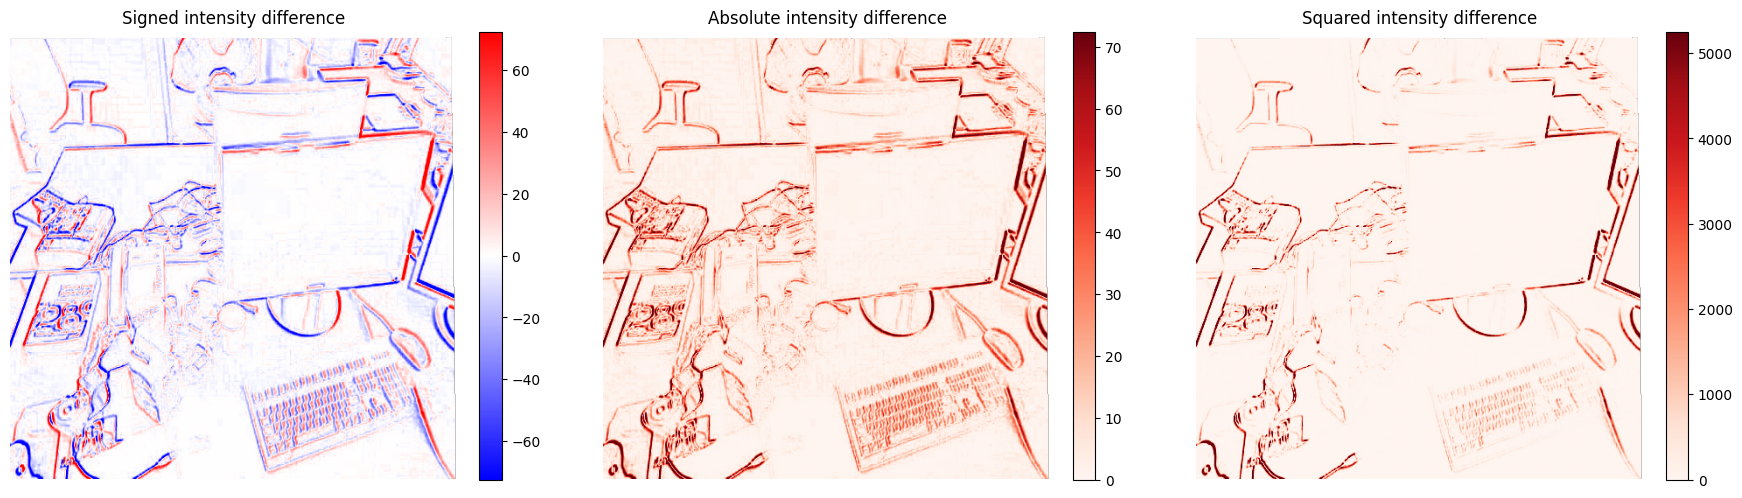

In [26]:
signed_diff_map = photometric_maps["signed_diff_map"]
abs_diff_map = photometric_maps["abs_diff_map"]
squared_diff_map = photometric_maps["squared_diff_map"]
valid_mask = photometric_maps["valid_mask"]

valid_signed = signed_diff_map[valid_mask]
vmax_signed = float(np.nanpercentile(np.abs(valid_signed), 99))
vmax_abs = float(np.nanpercentile(abs_diff_map[valid_mask], 99))
vmax_sq = float(np.nanpercentile(squared_diff_map[valid_mask], 99))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(signed_diff_map, cmap="bwr", vmin=-vmax_signed, vmax=vmax_signed)
axes[0].set_title("Signed intensity difference")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(abs_diff_map, cmap="Reds", vmin=0, vmax=vmax_abs)
axes[1].set_title("Absolute intensity difference")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(squared_diff_map, cmap="Reds", vmin=0, vmax=vmax_sq)
axes[2].set_title("Squared intensity difference")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [27]:
valid_pixel_count = int(valid_mask.sum())
total_pixel_count = int(valid_mask.size)
valid_pixel_ratio = float(valid_pixel_count / total_pixel_count)

mean_signed_difference = float(np.nanmean(signed_diff_map))
mean_absolute_difference = float(np.nanmean(abs_diff_map))
mean_squared_difference = float(np.nanmean(squared_diff_map))
max_absolute_difference = float(np.nanmax(abs_diff_map))
max_squared_difference = float(np.nanmax(squared_diff_map))

# Normalized metrics to compare runs independently of frame size and intensity scale.
normalized_mae_255 = float(mean_absolute_difference / 255.0)
normalized_mse_255 = float(mean_squared_difference / (255.0 ** 2))

print("Difference metrics on valid pixels:")
print("")
print("  valid pixel count        =", valid_pixel_count)
print("  total pixel count        =", total_pixel_count)
print("  valid pixel ratio        =", valid_pixel_ratio)
print("  mean signed difference   =", mean_signed_difference)
print("  mean absolute difference =", mean_absolute_difference)
print("  mean squared difference  =", mean_squared_difference)
print("  normalized MAE [0,1]     =", normalized_mae_255)
print("  normalized MSE [0,1]     =", normalized_mse_255)
print("  max absolute difference  =", max_absolute_difference)
print("  max squared difference   =", max_squared_difference)


Difference metrics on valid pixels:

  valid pixel count        = 255469
  total pixel count        = 262144
  valid pixel ratio        = 0.9745368957519531
  mean signed difference   = -0.9215476512908936
  mean absolute difference = 7.3598456382751465
  mean squared difference  = 258.0239562988281
  normalized MAE [0,1]     = 0.02886213975794175
  normalized MSE [0,1]     = 0.003968073145695165
  max absolute difference  = 168.31617736816406
  max squared difference   = 28330.333984375


In [28]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
frame_paths = real_frame_paths[:5]  # Remplace par fake_frame_paths[:5] si tu veux traiter la sequence fake.

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_keyframe = None
sequence_results = []

print(f"Processing {len(frame_paths)} frame(s) ...")

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)
    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        keyframe_image_path = image_path
        print(f"[frame {step:04d}] keyframe initialized: {image_path.name}")
        print(f"  depth valid ratio = {float(depth_valid_mask.mean()):.4f}")
        continue

    pose_solver.optPose(current_frame, sequence_keyframe)
    pose_matrix = current_frame.pose.as_matrix()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": pose_matrix,
    })

    print(f"[frame {step:04d}] {image_path.name}")
    print()
    print(f"  depth valid ratio = {float(depth_valid_mask.mean()):.4f}")
    print()
    print(pose_matrix)
    print("--------------------------------------------------------------")
    print()
    print()
    print()
    print()

print()
print(f"Done. Processed {len(sequence_results)} estimated pose(s) after the keyframe.")

Processing 5 frame(s) ...
[frame 0000] keyframe initialized: frame_00000.png
  depth valid ratio = 1.0000
lvl:  4  initial error:  2004.3798627002259
 error improvement too small, level converged! it:  4  error:  1305.6073934377307  lambda:  0.2
lvl:  3  initial error:  927.5661214071717
 error improvement too small, level converged! it:  5  error:  766.0649046942631  lambda:  879609302220.8
lvl:  2  initial error:  416.7498608729276
 error improvement too small, level converged! it:  3  error:  400.67174851802315  lambda:  51.2
[frame 0001] frame_00001.png

  depth valid ratio = 1.0000

[[ 0.999962 -0.004845  0.007187 -0.001391]
 [ 0.004913  0.999943 -0.009486  0.013646]
 [-0.00714   0.009521  0.999929 -0.035844]
 [ 0.        0.        0.        1.      ]]
--------------------------------------------------------------




lvl:  4  initial error:  3333.8798627002257
 error improvement too small, level converged! it:  5  error:  1058.8535447942481  lambda:  1.6
lvl:  3  initial error:  

In [29]:
import cv2
import numpy as np

image_path = r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\sequence_01\images\00000.jpg"

buffer = np.fromfile(image_path, dtype=np.uint8)
img = cv2.imdecode(buffer, cv2.IMREAD_COLOR)

if img is None:
    print("Impossible de charger l'image")
else:
    h, w = img.shape[:2]
    print(f"Resolution : {w} x {h}")

Resolution : 1280 x 1024
